# Proyecto - Limpieza de datos realistas

Utilizando un codigo en Python, previamente se generó una base de datos realista para hacer limpieza. 

In [1]:
# Importando librerias pandas y numpy
import pandas as pd
import numpy as np

In [2]:
# Localización absoluta de la libreta
import os
os.getcwd()

'C:\\Users\\lego_\\Documents'

In [3]:
# Localizacion de los archivos
file_name1 = "C:\\Users\\lego_\\Documents\\orders_dirty.csv"
file_name2 = "C:\\Users\\lego_\\Documents\\products_dirty.csv"
file_name3 = "C:\\Users\\lego_\\Documents\\customers_dirty.csv"

<h2> Limpieza para la tabla "Orders" </h2>

In [4]:
#Data frame "orders"
df_ord = pd.read_csv(file_name1)
df_ord.head()

,order_id,customer_id,product_id,order_date,quantity,price,total_amount
0,1,123,6,2023-03-31,1,355.49,355.49
1,2,27,3,2023-12-10,1,357.01,357.01
2,3,139,10,2023-12-16,2,134.30,268.60
3,4,73,16,2023-04-13,3,374.66,1123.98
4,5,179,1,2023-10-25,2,300.03,30003.00


Primero cambiamos los titulos

In [5]:
#Cambiamos los títulos
df_ord.rename(columns = {'order_id':'Order_ID', 'customer_id':'Customer_ID', 'product_id':'Product_ID',
                         'order_date':'Order_date', 'quantity':'Quantity','price':'Price',
                         'total_amount':'Total_amount'})

,Order_ID,Customer_ID,Product_ID,Order_date,Quantity,Price,Total_amount
0,1,123,6,2023-03-31,1,355.49,355.49
1,2,27,3,2023-12-10,1,357.01,357.01
2,3,139,10,2023-12-16,2,134.30,268.60
3,4,73,16,2023-04-13,3,374.66,1123.98
4,5,179,1,2023-10-25,2,300.03,30003.00
...,...,...,...,...,...,...,...
2555,1285,39,18,2023-03-10,2,126.38,252.76
2556,238,180,11,2023-06-28,3,208.55,625.65
2557,636,216,7,2023-02-16,3,131.87,395.61
2558,1007,220,4,2023-03-15,1,246.02,246.02


In [6]:
#"orders" info
df_ord.info()

<class 'pandas.DataFrame'>
RangeIndex: 2560 entries, 0 to 2559
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_id      2560 non-null   int64  
 1   customer_id   2560 non-null   int64  
 2   product_id    2560 non-null   int64  
 3   order_date    2560 non-null   str    
 4   quantity      2560 non-null   int64  
 5   price         2560 non-null   float64
 6   total_amount  2456 non-null   float64
dtypes: float64(2), int64(4), str(1)
memory usage: 140.1 KB


Con esto notamos que hay valores nulos en "Total_amount".

In [7]:
#"orders" tipos de dato
df_ord.dtypes 

order_id          int64
customer_id       int64
product_id        int64
order_date          str
quantity          int64
price           float64
total_amount    float64
dtype: object

In [8]:
#"orders" valores estadisticos
df_ord.describe()

,order_id,customer_id,product_id,quantity,price,total_amount
count,2560.000000,2560.000000,2560.000000,2560.000000,2560.000000,2456.000000
mean,1247.458594,149.430469,10.275781,1.993359,222.041852,510.250619
std,721.041258,86.678566,5.771109,0.821955,126.224316,1491.996797
min,1.000000,1.000000,1.000000,1.000000,-50.000000,-7500.000000
25%,623.750000,72.000000,5.000000,1.000000,171.820000,222.880000
50%,1247.500000,149.000000,10.000000,2.000000,208.550000,390.420000
75%,1871.250000,226.000000,15.000000,3.000000,343.710000,668.640000
max,2500.000000,300.000000,20.000000,3.000000,413.170000,41317.000000


Podemos notar que el máx en "total_amount" es mayor a 40000, cuando el precio más alto de un item es menor a 500 y la cantidad comprada es máximo 3, lo que es incosistente. También notamos que hay valores negativos en "price".

Buscamos los valores donde el precio es negativo:

In [9]:
df_ord.query("price < 0")

,order_id,customer_id,product_id,order_date,quantity,price,total_amount
26,27,28,13,2023-08-25,2,-50.0,-100.0
27,28,112,12,2023-09-16,2,-50.0,-100.0
28,29,141,12,2023-12-09,2,-50.0,-100.0
39,40,65,13,2023-08-19,1,-50.0,-50.0
62,63,40,13,2026-01-01,3,-50.0,-150.0
...,...,...,...,...,...,...,...
2511,1283,134,13,2023-05-16,3,-50.0,-150.0
2514,1576,4,12,2023-02-28,3,-50.0,-150.0
2531,633,9,12,2023-06-20,2,-50.0,-100.0
2538,133,166,12,2023-03-08,1,-50.0,-50.0


In [10]:
neg_vals = df_ord.query("price < 0")["product_id"]
neg_vals.unique()

array([13, 12])

In [11]:
df_ord.query('product_id in [12,13] and price>0')

,order_id,customer_id,product_id,order_date,quantity,price,total_amount


Todos artículos con "product_id" 12 y 13 tienen precios negativos. A falta de más información, los removemos. 

In [12]:
df_ord = df_ord.query('price>0')

Corregimos los valores en "total_amount".

In [13]:
df_ord['total_amount'] = df_ord['price']*df_ord['quantity']  

Hemos realizamos el calculo correctamente.

Convertimos los datos de tipo "string" a "datatime":

In [14]:
df_ord["order_date"] = pd.to_datetime(df_ord["order_date"]) 

In [15]:
df_ord.dtypes

order_id                 int64
customer_id              int64
product_id               int64
order_date      datetime64[us]
quantity                 int64
price                  float64
total_amount           float64
dtype: object

In [16]:
len(df_ord[df_ord["order_date"] > pd.Timestamp.today()]) 

0

Consultamos las fechas posteriores a la fecha de hoy (2026-04-30), lo que muestra que <b>no</b> hay fechas con valores futuros

Buscamos los valores nulos y duplicados

In [17]:
df_ord.isna().sum()

order_id        0
customer_id     0
product_id      0
order_date      0
quantity        0
price           0
total_amount    0
dtype: int64

No hay más valores faltantes en "total_amount". Buscamos valores duplicados:

In [18]:
df_ord.loc[df_ord.duplicated()]

,order_id,customer_id,product_id,order_date,quantity,price,total_amount
2500,507,250,15,2023-06-28,1,413.17,413.17
2502,355,117,18,2023-09-09,3,126.38,379.14
2503,1081,17,5,2023-01-02,1,195.21,195.21
2504,2390,72,17,2023-01-29,1,343.71,343.71
2505,1643,200,2,2023-02-25,1,181.61,181.61
2506,1569,229,20,2023-02-02,1,244.08,244.08
2507,636,216,7,2023-02-16,3,131.87,395.61
2508,2363,70,5,2023-08-07,1,195.21,195.21
2509,1742,260,3,2023-03-11,3,357.01,1071.03
2510,1564,286,8,2023-06-06,1,171.82,171.82


In [19]:
df_ord.query('order_id == 507')

,order_id,customer_id,product_id,order_date,quantity,price,total_amount
506,507,250,15,2023-06-28,1,413.17,413.17
2500,507,250,15,2023-06-28,1,413.17,413.17


Notamos que hay filas duplicadas que no aportan información.

In [20]:
df_ord = df_ord.loc[~df_ord.duplicated()].reset_index(drop=True).copy()

Hemos guardado una copia que omite los valores duplicados.

La tabla "Orders" ha sido limpiada.

<h2> Limpieza para la tabla "Products" </h2>

In [21]:
#Data frame "products"
df_pr = pd.read_csv(file_name2)
df_pr.head()

,product_id,category,price
0,1,electrnics,300.03
1,2,Clothing,181.61
2,3,Home,357.01
3,4,Clothing,246.02
4,5,Clothing,195.21


In [22]:
#Información de la tabla de productos
df_pr.info

<bound method DataFrame.info of     product_id     category   price
0            1   electrnics  300.03
1            2     Clothing  181.61
2            3         Home  357.01
3            4     Clothing  246.02
4            5     Clothing  195.21
5            6   electrnics  355.49
6            7  Electronics  131.87
7            8  Electronics  171.82
8            9     Clothing  222.88
9           10         Home  134.30
10          11       Beauty  208.55
11          12       Beauty  -50.00
12          13  Electronics  -50.00
13          14  Electronics  385.93
14          15     Clothing  413.17
15          16       Beauty  374.66
16          17  Electronics  343.71
17          18         Home  126.38
18          19         Home  206.11
19          20  Electronics  244.08>

In [23]:
#tipos de dato en la tabla "productos"
df_pr.dtypes 

product_id      int64
category          str
price         float64
dtype: object

In [24]:
#Tamaño de la tabla 
df_pr.shape

(20, 3)

In [25]:
df_pr.describe(include=["str"])

,category
count,20
unique,5
top,Electronics
freq,6


In [26]:
df_pr.describe()

,product_id,price
count,20.00000,20.000000
mean,10.50000,224.941500
std,5.91608,130.342052
min,1.00000,-50.000000
25%,5.75000,162.440000
50%,10.50000,215.715000
75%,15.25000,346.655000
max,20.00000,413.170000


Notamos que hay valores negativos en "price". Los eliminamos y reiniciamos los indices.

In [27]:
df_pr = df_pr[df_pr['price']>0]

In [28]:
df_pr.reset_index(drop=True)

,product_id,category,price
0,1,electrnics,300.03
1,2,Clothing,181.61
2,3,Home,357.01
3,4,Clothing,246.02
4,5,Clothing,195.21
5,6,electrnics,355.49
6,7,Electronics,131.87
7,8,Electronics,171.82
8,9,Clothing,222.88
9,10,Home,134.30


Revisamos qué nombres están mal escritos en "categorias".

In [29]:
df_pr['category'].value_counts()

category
Clothing       5
Electronics    5
Home           4
electrnics     2
Beauty         2
Name: count, dtype: int64

In [30]:
df_pr.replace({"electrnics":"Electronics"})

,product_id,category,price
0,1,Electronics,300.03
1,2,Clothing,181.61
2,3,Home,357.01
3,4,Clothing,246.02
4,5,Clothing,195.21
5,6,Electronics,355.49
6,7,Electronics,131.87
7,8,Electronics,171.82
8,9,Clothing,222.88
9,10,Home,134.30


<h2> Limpieza para la tabla "custumers" </h2>

In [31]:
#Data frame "custumers"
df_cus = pd.read_csv(file_name3)
df_cus.head()

,customer_id,country,signup_date
0,1,Mexico,2023-09-27
1,2,Mexico,2023-06-11
2,3,Colombia,2023-07-08
3,4,Mexico,2023-09-04
4,5,Mexico,2023-08-04


In [32]:
#Información de la tabla de productos
df_cus.info

<bound method DataFrame.info of      customer_id   country signup_date
0              1    Mexico  2023-09-27
1              2    Mexico  2023-06-11
2              3  Colombia  2023-07-08
3              4    Mexico  2023-09-04
4              5    Mexico  2023-08-04
..           ...       ...         ...
295          296  Colombia  2023-11-07
296          297  Colombia  2023-10-29
297          298       USA  2023-02-01
298          299       USA  2023-02-24
299          300    Mexico  2023-12-18

[300 rows x 3 columns]>

In [33]:
df_cus.dtypes

customer_id    int64
country          str
signup_date      str
dtype: object

In [34]:
df_cus.shape

(300, 3)

In [35]:
df_cus.describe(include='all')

,customer_id,country,signup_date
count,300.000000,290,300
unique,NaN,4,208
top,NaN,Mexico,2023-10-10
freq,NaN,107,5
mean,150.500000,NaN,NaN
std,86.746758,NaN,NaN
min,1.000000,NaN,NaN
25%,75.750000,NaN,NaN
50%,150.500000,NaN,NaN
75%,225.250000,NaN,NaN


In [36]:
df_cus.describe(include = ["str"])

,country,signup_date
count,290,300
unique,4,208
top,Mexico,2023-10-10
freq,107,5


In [37]:
df_cus["country"].value_counts()

country
Mexico      107
Colombia     97
USA          81
Mx            5
Name: count, dtype: int64

Estandarizamos los nombres de los paises:

In [38]:
df_cus.replace({"Mx":"Mexico"})

,customer_id,country,signup_date
0,1,Mexico,2023-09-27
1,2,Mexico,2023-06-11
2,3,Colombia,2023-07-08
3,4,Mexico,2023-09-04
4,5,Mexico,2023-08-04
...,...,...,...
295,296,Colombia,2023-11-07
296,297,Colombia,2023-10-29
297,298,USA,2023-02-01
298,299,USA,2023-02-24


Hay 10 valores nulos en "country".

In [46]:
df_cus.isna().sum()

customer_id     0
country        10
signup_date     0
dtype: int64

In [39]:
filas_con_nulos = df_cus[df_cus.isna().any(axis=1)]
filas_con_nulos

,customer_id,country,signup_date
5,6,NaN,2023-11-11
34,35,NaN,2023-11-24
35,36,NaN,2023-05-04
96,97,NaN,2023-07-27
108,109,NaN,2023-01-20
109,110,NaN,2023-02-10
136,137,NaN,2023-05-30
176,177,NaN,2023-02-10
212,213,NaN,2023-04-01
294,295,NaN,2023-08-25


Imprimimos todas las filas que tengan algun "customer_id" de valores nulos para revisar si hay más información. 

In [40]:
for j in filas_con_nulos['customer_id']:
    print(df_cus[ df_cus['customer_id'] == j ] )

   customer_id country signup_date
5            6     NaN  2023-11-11
    customer_id country signup_date
34           35     NaN  2023-11-24
    customer_id country signup_date
35           36     NaN  2023-05-04
    customer_id country signup_date
96           97     NaN  2023-07-27
     customer_id country signup_date
108          109     NaN  2023-01-20
     customer_id country signup_date
109          110     NaN  2023-02-10
     customer_id country signup_date
136          137     NaN  2023-05-30
     customer_id country signup_date
176          177     NaN  2023-02-10
     customer_id country signup_date
212          213     NaN  2023-04-01
     customer_id country signup_date
294          295     NaN  2023-08-25


Como no hay mas información, borramos todas las filas.

In [41]:
df_cus = df_cus.dropna()

In [42]:
df_cus.isna().sum()

customer_id    0
country        0
signup_date    0
dtype: int64

Ya no hay valores nulos en "country".

In [43]:
df_cus["signup_date"].value_counts()

signup_date
2023-10-10    5
2023-03-24    4
2023-12-04    4
2023-03-14    4
2023-06-17    3
             ..
2023-02-21    1
2023-12-10    1
2023-10-29    1
2023-02-01    1
2023-02-24    1
Name: count, Length: 204, dtype: int64

Verificamos que no haya fechas incorrectas:

In [44]:
df_cus["signup_date"] = pd.to_datetime(df_cus["signup_date"]) 

In [45]:
len(df_cus[df_cus["signup_date"] > pd.Timestamp.today()]) 

0

No hay fechas inconsistentes

Verificamos consistencia entre las tablas

In [46]:
prices = df_ord.merge(df_pr, on="product_id", how="outer", indicator=True)
prices

,order_id,customer_id,product_id,order_date,quantity,price_x,total_amount,category,price_y,_merge
0,5,179,1,2023-10-25,2,300.03,600.06,electrnics,300.03,both
1,48,42,1,2023-11-12,2,300.03,600.06,electrnics,300.03,both
2,50,215,1,2023-07-14,3,300.03,900.09,electrnics,300.03,both
3,51,260,1,2023-09-12,1,300.03,300.03,electrnics,300.03,both
4,77,281,1,2023-10-12,1,300.03,300.03,electrnics,300.03,both
...,...,...,...,...,...,...,...,...,...,...
2240,2408,139,20,2023-03-01,2,244.08,488.16,Electronics,244.08,both
2241,2421,230,20,2023-10-23,1,244.08,244.08,Electronics,244.08,both
2242,2432,202,20,2023-02-26,1,244.08,244.08,Electronics,244.08,both
2243,2433,67,20,2023-01-19,2,244.08,488.16,Electronics,244.08,both


In [47]:
len(prices.loc[ prices["price_x"] != prices['price_y'] ] )

0

Los precios en ambas tablas son iguales.

<h2>Revisión de KPIs</h2> 

In [48]:
df_ord.describe(include = 'all')

,order_id,customer_id,product_id,order_date,quantity,price,total_amount
count,2245.000000,2245.000000,2245.000000,2245,2245.000000,2245.000000,2245.000000
mean,1261.031180,150.064143,10.028062,2023-07-17 05:55:20.979955,2.002673,253.565947,509.814004
min,1.000000,1.000000,1.000000,2023-01-01 00:00:00,1.000000,126.380000,126.380000
25%,639.000000,73.000000,5.000000,2023-04-11 00:00:00,1.000000,181.610000,263.740000
50%,1266.000000,149.000000,9.000000,2023-07-08 00:00:00,2.000000,222.880000,412.220000
75%,1879.000000,227.000000,16.000000,2023-10-04 00:00:00,3.000000,355.490000,710.980000
max,2500.000000,300.000000,20.000000,2026-01-01 00:00:00,3.000000,413.170000,1239.510000
std,719.382525,86.915147,6.039503,NaN,0.819760,91.725902,292.446155


In [49]:
df_pr.describe(include = 'all')

,product_id,category,price
count,18.000000,18,18.000000
unique,NaN,5,NaN
top,NaN,Clothing,NaN
freq,NaN,5,NaN
mean,10.277778,NaN,255.490556
std,6.210101,NaN,95.427182
min,1.000000,NaN,126.380000
25%,5.250000,NaN,185.010000
50%,9.500000,NaN,233.480000
75%,15.750000,NaN,352.545000


In [58]:
df_cus.describe(include = 'all')

,customer_id,country,signup_date
count,290.000000,290,290
unique,NaN,4,NaN
top,NaN,Mexico,NaN
freq,NaN,107,NaN
mean,151.500000,NaN,2023-07-02 07:46:45.517241
min,1.000000,NaN,2023-01-02 00:00:00
25%,76.250000,NaN,2023-03-25 00:00:00
50%,152.500000,NaN,2023-06-26 12:00:00
75%,226.750000,NaN,2023-10-10 00:00:00
max,300.000000,NaN,2023-12-29 00:00:00


Calculamos el valor de los <b>ingresos totales (revenue)</b>:

In [57]:
rev = df_ord['total_amount'].sum()
rev

np.float64(1144532.44)

El <b>número de ordenes</b> es:

In [61]:
n_ventas = df_ord['quantity'].sum()
n_ventas

np.int64(4496)

Calculamos el <b>ticket promedio (AOV) </b>:

$$
\text{Ticket promedio} = \frac{\text{Ingresos totales}}{\text{Número de ventas}}
$$

In [62]:
AOV = rev / n_ventas
AOV

np.float64(254.56682384341636)

Enlistamos a los <b>clientes únicos</b>:

In [71]:
unique_clients = df_ord['customer_id'].unique()
unique_clients.sort()
unique_clients

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

Calculamos el <b>ingreso por cliente</b>: 

In [80]:
ing_per_client = df_ord[['customer_id','total_amount']]
ing_per_client.groupby('customer_id').mean()

,total_amount
customer_id,
1,440.318571
2,468.586667
3,420.390000
4,538.476667
5,421.061429
...,...
296,466.671111
297,415.494286
298,388.170000


Mostramos a los 100 mejores compradores:

In [111]:
best_clients = ing_per_client.sort_values(by='total_amount', ascending=False).head(100)
best_clients

,customer_id,total_amount
2222,204,1239.51
28,109,1239.51
2131,274,1239.51
2029,88,1239.51
1725,62,1239.51
...,...,...
1152,248,1123.98
1097,78,1123.98
1086,85,1123.98
640,172,1123.98


In [85]:
%pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


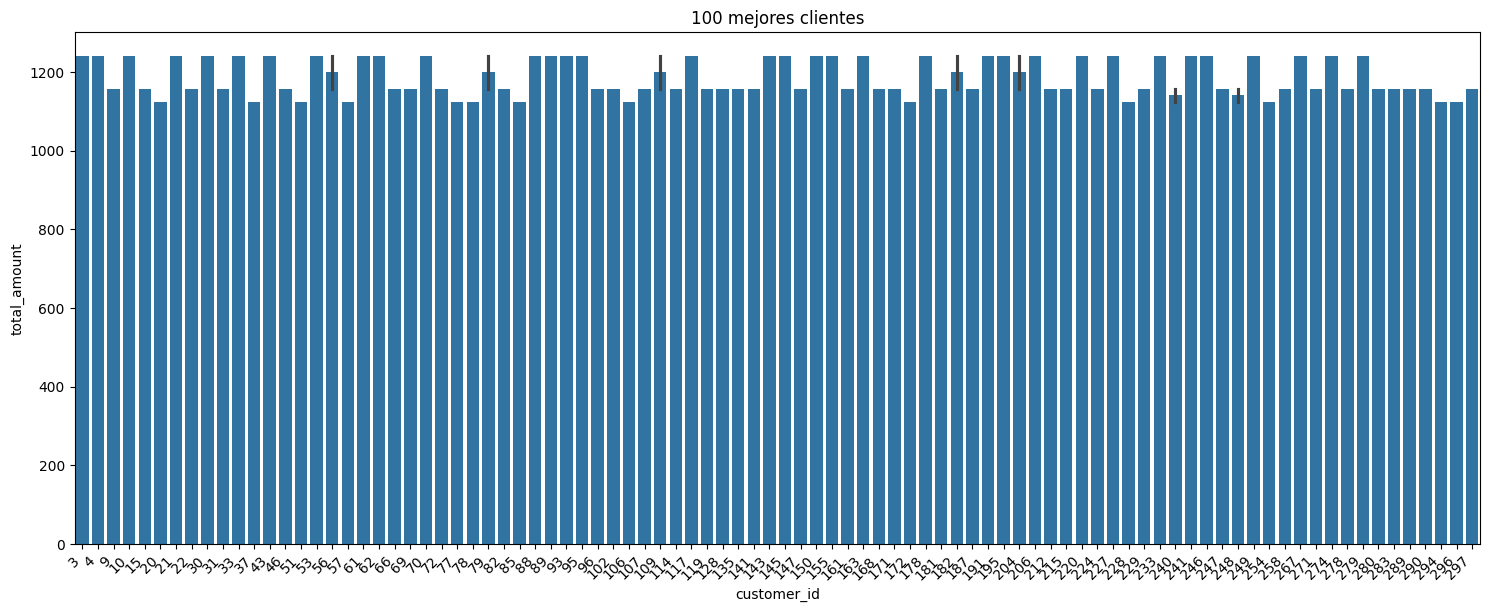

In [112]:
plt.figure(figsize=(15, 6))
sns.barplot(x=best_clients['customer_id'], y=best_clients['total_amount'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.title('100 mejores clientes')
plt.show()

Visualizamos el rango de ingresos de los 100 mejores compradores

### Descargamos los archivos 

In [113]:
df_ord.to_csv('orders_cleaned.csv', index=False)
df_pr.to_csv('products_cleaned.csv', index=False)
df_cus.to_csv('customers_cleaned.csv', index=False)